In [1]:
import sys
import os


from tqdm import tqdm
import time


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


sys.path.append(os.path.abspath(".."))
from package.BPETokenizer import * 
from package.TextDataset import * 
from package.GPT import * 
from package.Engine import * 


import matplotlib.pyplot as plt


from IPython.display import clear_output, display

%load_ext autoreload
%autoreload 2

In [2]:
model_architecture ={
    "context_window" : 128,
    "batch_size" : 64,
    "d_emb" : 256,
    "nb_heads" : 4,
    #d_k = d_emb // nb_heads
    "nb_layers" : 6
}

In [3]:
sliding_windows = 0.

context_window = 128
batch_size = 32

d_emb = 400
nb_heads = 4
d_k = d_emb // nb_heads

nb_layers = 7

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#device = torch.device("cpu")
print(device)

mps


In [4]:
tokenizer = BPETokenizer()
tokens = torch.tensor(tokenizer.load_tokens("tokens_bpe.tok"))
print(tokens.shape)


vocab_size = tokenizer.vocab_size
print("vocab_size : " , vocab_size)

dataset = TextDataset(tokens,context_window=context_window,sliding_windows=sliding_windows)
print("dataset_size : " ,len(dataset))


loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers = 2
)


Don't forget to load your tokenizer
torch.Size([3179243])
vocab_size :  4000
dataset_size :  3179116


In [5]:
gpt = GPT(vocab_size=vocab_size, context_window=context_window, d_emb=d_emb,nb_layers=nb_layers,nb_heads=nb_heads).to(device)
gpt.architecture()

PARAMETERS :
embedding.E.weight: mps:0 torch.Size([4000, 400]) 1600000
embedding.P.weight: mps:0 torch.Size([128, 400]) 51200
transformer_blocks.0.norm1.weight: mps:0 torch.Size([400]) 400
transformer_blocks.0.norm1.bias: mps:0 torch.Size([400]) 400
transformer_blocks.0.norm2.weight: mps:0 torch.Size([400]) 400
transformer_blocks.0.norm2.bias: mps:0 torch.Size([400]) 400
transformer_blocks.0.attention.Wq.weight: mps:0 torch.Size([400, 400]) 160000
transformer_blocks.0.attention.Wk.weight: mps:0 torch.Size([400, 400]) 160000
transformer_blocks.0.attention.Wv.weight: mps:0 torch.Size([400, 400]) 160000
transformer_blocks.0.attention.Wo.weight: mps:0 torch.Size([400, 400]) 160000
transformer_blocks.0.feed_forward.NN.0.weight: mps:0 torch.Size([1200, 400]) 480000
transformer_blocks.0.feed_forward.NN.0.bias: mps:0 torch.Size([1200]) 1200
transformer_blocks.0.feed_forward.NN.2.weight: mps:0 torch.Size([400, 1200]) 480000
transformer_blocks.0.feed_forward.NN.2.bias: mps:0 torch.Size([400]) 40

In [6]:
engine = Engine(gpt,tokenizer,device)
print(len(iter(loader)))

99347


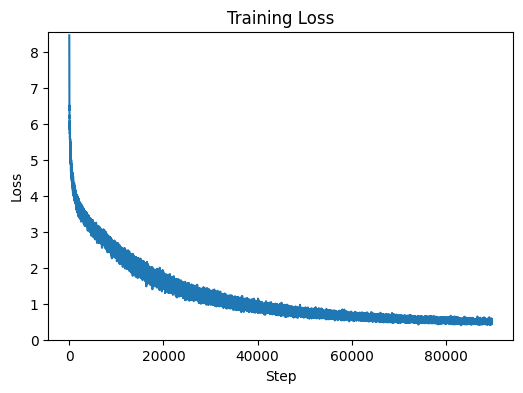

|----------------------------------------| 0/1 [15022.5s<0.0s, 0.0 it/s]
|███████████████████████████████████████-| 29800/30000 [15022.5s<100.8s, 2.0 it/s]
je pense que genres n'est point un jour aussi sublimement ne pourra parvenir a l'auteur des provinments des hommes ; un attachement rais


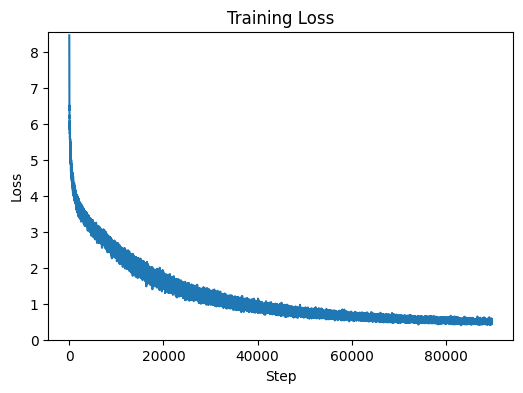

In [12]:
engine.train(loader,1,2000,30000,print_frequency=200)
engine.save_model("training_historic/final.w")

In [20]:
engine.save("training_historic/final.e")



In [24]:
init = "bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense que la revolution a eu un impact catastrophique sur la france. pour l'affirmer je fais appel a l'autorite du pape leon. bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense que la revolution a eu un impact catastrophique sur la france. pour l'affirmer je fais appel a l'autorite du pape leon. bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense que "

out = engine.generate(init,max_new_tokens=200,temperature=0.9,k=20)
print(out[678:])

je pense que j'ai jamais servi de mes ouvrages ; resultes par l'etat de la methode de l'etat, il me semble que ma jeunesse, pour que j'ai ose les promettatoiter a dieu et qui est a mon pays. en ce cas, je n'aurais pas le parents traitre de cette femme un demi-rais ne se rejouiraient pas de ma presence passee. la malediction qui s'etait empare de mon mal, console au secret de ses droits et de mes chagrins de cette paroidrale, nous lui demandames le pere caronian dans la chambre du duc d'enghien. je l'ignore : vous serez donc a faire perir entre la facheuse que vous m'avez fait sentir aujourd'hui en syrie ; vous n'y repondit rien que, plus miserable que ce lis tomba de discours a des dangers. je


In [ ]:
engine.losses

[8.480131149291992,
 8.302947998046875,
 8.144103050231934,
 7.976662635803223,
 7.8263750076293945,
 7.668027877807617,
 7.532865047454834,
 7.388607025146484,
 7.293431758880615,
 7.209194183349609,
 7.164431571960449,
 7.084841728210449,
 7.0352678298950195,
 6.970945358276367,
 6.873078346252441,
 6.87846040725708,
 6.834338188171387,
 6.759645462036133,
 6.741162300109863,
 6.719182014465332,
 6.661777496337891,
 6.601193428039551,
 6.672337055206299,
 6.597940444946289,
 6.5939040184021,
 6.536235809326172,
 6.5790324211120605,
 6.529242515563965,
 6.496466636657715,
 6.454572677612305,
 6.450976371765137,
 6.467485427856445,
 6.552668571472168,
 6.43597936630249,
 6.453334331512451,
 6.461654186248779,
 6.426224708557129,
 6.488633155822754,
 6.350164413452148,
 6.4282402992248535,
 6.4077253341674805,
 6.375480651855469,
 6.407116889953613,
 6.35406494140625,
 6.41666841506958,
 6.412684440612793,
 6.382014751434326,
 6.363339900970459,
 6.395510196685791,
 6.397320747375488,
 

In [2]:
engine  = Engine.load("training_historic/final.e")

In [4]:
engine.model

GPT(
  (embedding): EmbeddingLayer(
    (E): Embedding(4000, 400)
    (P): Embedding(128, 400)
  )
  (transformer_blocks): ModuleList(
    (0-6): 7 x TransformerLayer(
      (norm1): LayerNorm((400,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((400,), eps=1e-05, elementwise_affine=True)
      (attention): MultiHeadAttention(
        (Wq): Linear(in_features=400, out_features=400, bias=False)
        (Wk): Linear(in_features=400, out_features=400, bias=False)
        (Wv): Linear(in_features=400, out_features=400, bias=False)
        (Wo): Linear(in_features=400, out_features=400, bias=False)
      )
      (feed_forward): FeedForwardLayer(
        (NN): Sequential(
          (0): Linear(in_features=400, out_features=1200, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1200, out_features=400, bias=True)
        )
      )
    )
  )
  (final_norm): LayerNorm((400,), eps=1e-05, elementwise_affine=True)
  (linear_head): Linear(in_featur